# Solução 01: Erosão

Esta solução visa utilizar da técnica de erosão para checar se existe ou não a letra "A" na imagem.

# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Methods

In [3]:
def find_contorno(imagem):
    """Verifica se a imagem contém a letra A maiúscula"""
    # Binariza a imagem (inversão: fundo branco, letras pretas)
    _, img_bin = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Encontra contornos (possíveis letras)
    contornos, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contornos, img_bin

def tm_ccoef_normed(image: np.ndarray, template: np.ndarray) -> np.ndarray:
    """
    Calcula a correlação cruzada normalizada (TM_CCOEFF_NORMED) entre a imagem e o template.

    Parâmetros:
    - image: imagem de entrada (2D, em escala de cinza)
    - template: template a ser comparado (2D, em escala de cinza)

    Retorna:
    - result: mapa de similaridade (valores entre -1 e 1)
    """
    img_h, img_w = image.shape
    tpl_h, tpl_w = template.shape

    # Média e T' do template
    template_mean = np.mean(template)
    template_prime = template - template_mean
    template_prime_squared_sum = np.sum(template_prime ** 2)

    # Saída terá tamanho reduzido
    result_h = img_h - tpl_h + 1
    result_w = img_w - tpl_w + 1
    result = np.zeros((result_h, result_w), dtype=np.float32)

    # Para cada posição possível (x, y) na imagem:
    for y in range(result_h):
        for x in range(result_w):
            region = image[y:(y + tpl_h), x:(x + tpl_w)]
            region_mean = np.mean(region)
            region_prime = region - region_mean
            region_prime_squared_sum = np.sum(region_prime ** 2)

            numerator = np.sum(template_prime * region_prime)
            denominator = np.sqrt(template_prime_squared_sum * region_prime_squared_sum)

            result[y, x] = numerator / denominator if denominator != 0 else 0.0

    return result


# Parameters

In [4]:
path_assets = PROJECT_DIR / 'assets'

# Questão 08

## 1) Leituras das imagens

In [5]:
image_path_1 = str(path_assets / "atv02_lista02-assets" / "Book_1.png")
image_path_2 = str(path_assets / "atv02_lista02-assets" / "Book_2.png")

image_book1 = cv2.imread(image_path_1, cv2.IMREAD_GRAYSCALE)
image_book2 = cv2.imread(image_path_2, cv2.IMREAD_GRAYSCALE)

## 2) Pegando o template ideal

Visualmente, podemos ver que a letra "A" maiuscula so aparece na primeira imagem, logo vamos tentar aplicar um recorte dessa imagem, para obtermos um template para uso como *struct* em um método de eroão.

In [6]:
# Configurando cortes das imagens para procura
cortes = {
    "Imagem completa": ((0, image_book1.shape[0]), (0, image_book1.shape[1])),
    "Primeiro corte": ((0, image_book1.shape[0]), (55, 87)),
    "Segundo corte": ((470, 570), (55, 87)),
    "Template final": ((501, 529), (57, 86))
}

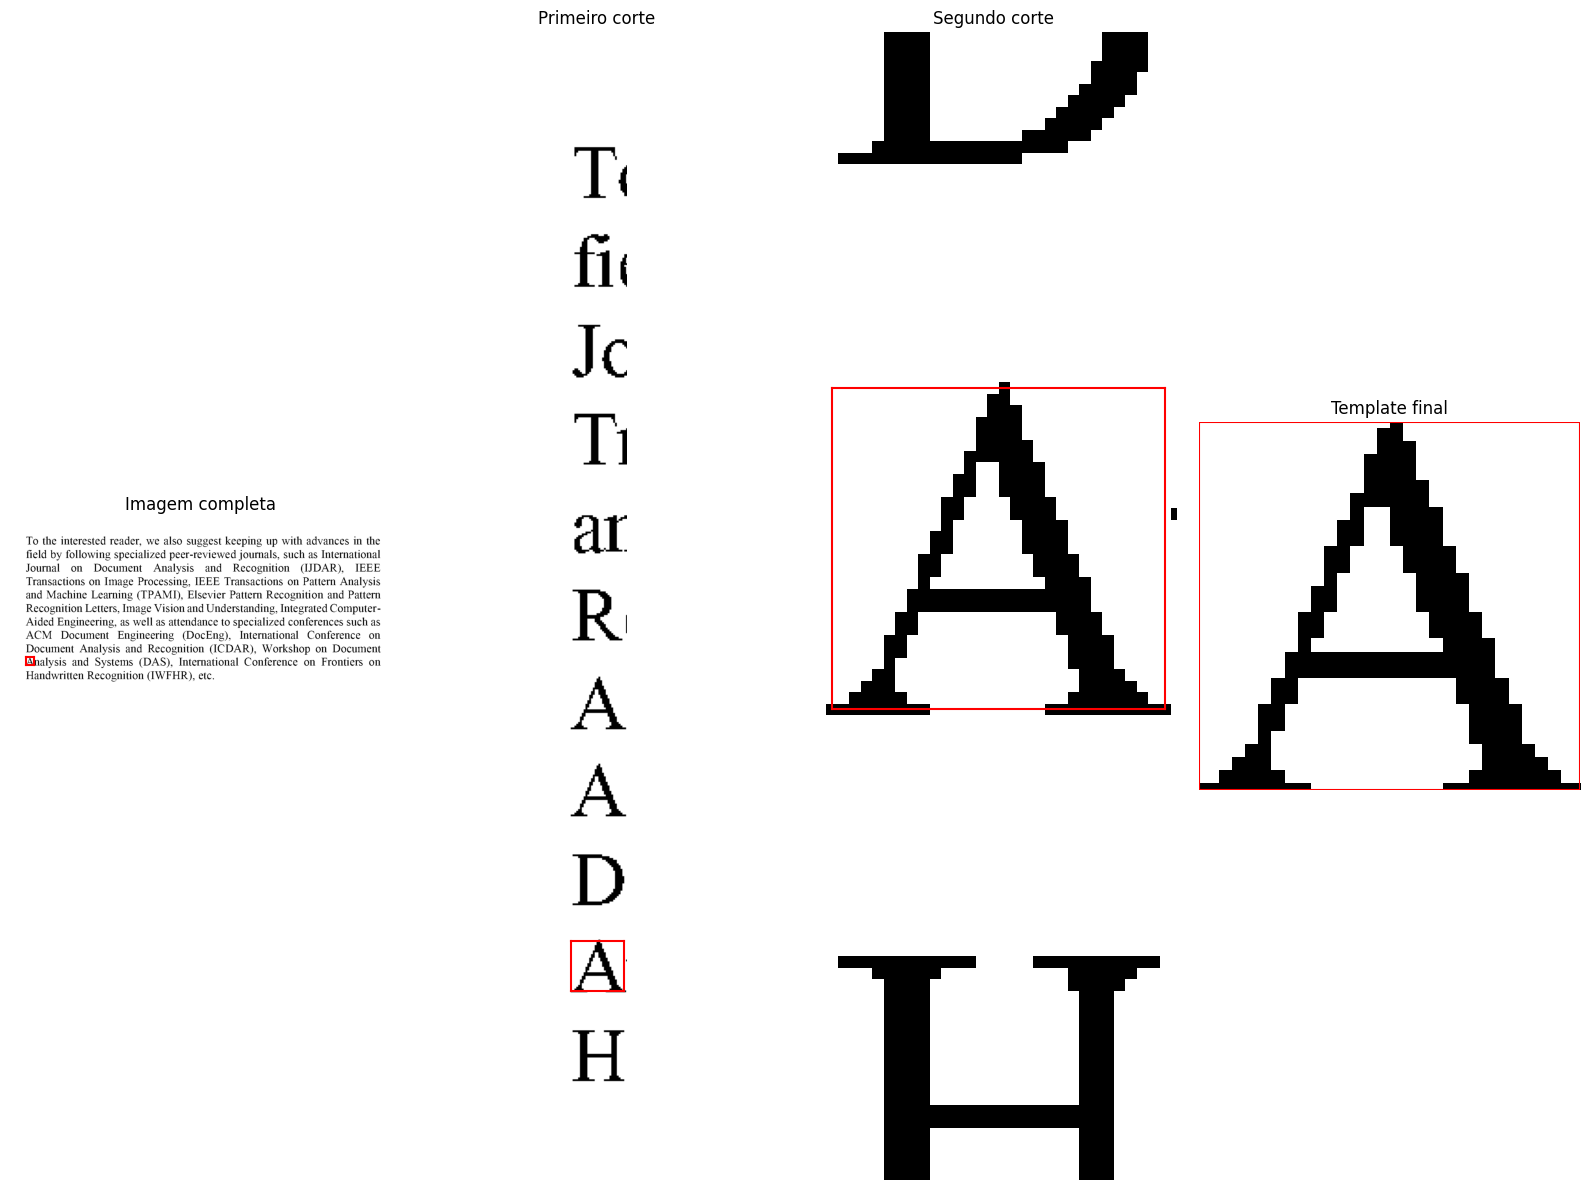

In [7]:

fig, ax = plt.subplots(1, len(cortes), figsize=(16, 12))
if not isinstance(ax, np.ndarray):
    ax = np.array([ax])
for idx, (title, sliced) in enumerate(cortes.items()):
    ax[idx].imshow(image_book1, cmap='gray')
    ax[idx].axis('off')
    if idx > 0:
        ax[idx].set_ylim(sliced[0][1], sliced[0][0])
        ax[idx].set_xlim(sliced[1][0], sliced[1][1])

    #if idx == 0:
    x_init, x_end = cortes["Template final"][1]
    y_init, y_end = cortes["Template final"][0]
    ax[idx].plot(
        [x_init] * np.ones(len(np.arange(y_init, y_end +1 ))),
        np.arange(y_init, y_end + 1),
        color='red',
        label='Média da linha'
    )

    ax[idx].plot(
        [x_end] * np.ones(len(np.arange(y_init, y_end+ 1))),
        np.arange(y_init, y_end + 1),
        color='red',
        label='Média da linha'
    )
    ax[idx].plot(
        np.arange(x_init, x_end+ 1),
        [y_init] * len(np.arange(x_init, x_end+ 1)),
        color='red',
        label='Média da linha'
    )

    ax[idx].plot(
        np.arange(x_init, x_end+ 1),
        [y_end] * len(np.arange(x_init, x_end+ 1)),
        color='red',
        label='Média da linha'
    )
    ax[idx].set_title(title)

fig.tight_layout()
fig.savefig(path_assets / "atv02-q08-s1-00.png", dpi=400, bbox_inches='tight')
plt.show()

Logo

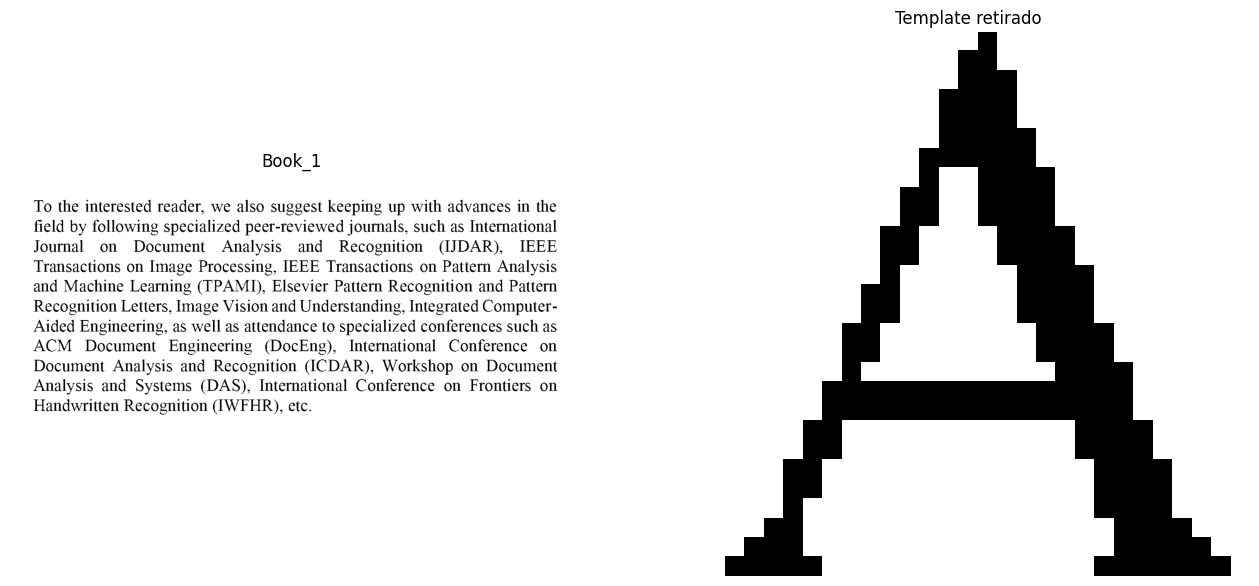

In [8]:
template = image_book1[
    slice(*cortes["Template final"][0]),
    slice(*cortes["Template final"][1])
]
fig, ax = plt.subplots(1, 2, figsize=(16, 10))

ax[0].imshow(
    image_book1, cmap="gray"
)
ax[0].set_title("Book_1")
ax[1].imshow(
    template,
    cmap='gray'
)
ax[1].set_title("Template retirado")
for _ax in ax:
    _ax.axis("off")

fig.savefig(path_assets / "atv02-q08-s1-04.png", dpi=400, bbox_inches='tight')

## 3) Binarização

In [9]:
_, template_mask = cv2.threshold(template, 127, 255, cv2.THRESH_BINARY_INV)
_, image_mask_1 = cv2.threshold(image_book1, 127, 255, cv2.THRESH_BINARY_INV)
_, image_mask_2 = cv2.threshold(image_book2, 127, 255, cv2.THRESH_BINARY_INV)

In [10]:
imgs_mask = {
    "Book_1 - Binarizado": image_mask_1,
    "Book_2 - Binarizado": image_mask_2,
    "Template - Binarizado": template_mask
}
lista_books = list(imgs_mask.keys())[:(-1)]

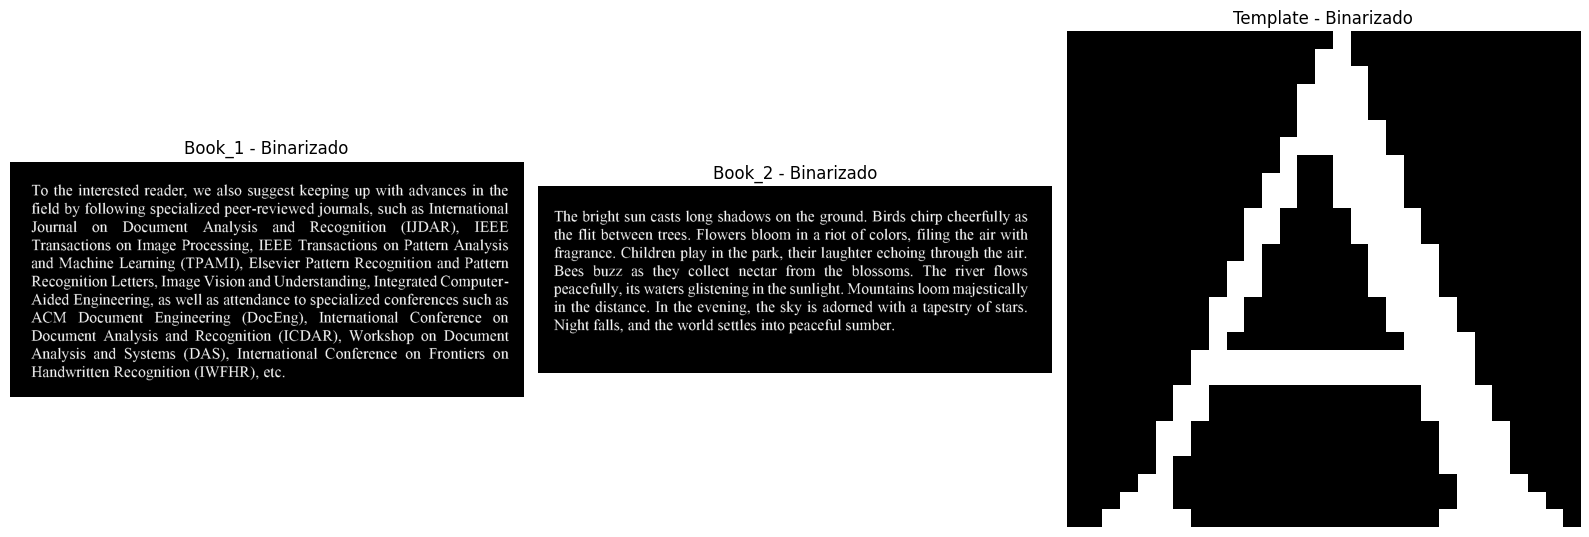

In [11]:
fig, ax = plt.subplots(1, len(imgs_mask.keys()), figsize=(16, 10))

for (title, content), _ax in zip(imgs_mask.items(), ax.flatten()):
    _ax.imshow(
        content,
        cmap="gray"
    )
    _ax.set_title(title)
    _ax.axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv02-q08-s1-02.png", dpi=400, bbox_inches='tight')
plt.show()

## 4) Aplicando o processo de erosão sobre o template anterior

Neste momento, vamos aplicar o processo de erosão sobre o template, que será considerado o nosso struct.

In [12]:
# Aplicar erosão morfológica usando o template como struct
eroded_results = {}
for name in lista_books:
    eroded_results[name] = {
        "eroded": cv2.erode(
            imgs_mask[name],
            template_mask,
            iterations=1
        ) / 255  # Normalizando para 0-1
    }
    eroded_results[name]["contains_A"] = bool(eroded_results[name]["eroded"].sum() > 0)
    eroded_results[name]["total-of_A"] = int(eroded_results[name]["eroded"].sum())

Vamos aplicar uma dilatação apenas para visualizar melhor os locais encontrados

In [13]:
# Aplicando uma dilatação apenas para visualizar melhor a localização dos A encontrados
dilated = {}
k_iter = 3
for name in lista_books:
    dilated[name] = cv2.dilate(
        eroded_results[name]["eroded"].astype(np.uint8),
        kernel=np.ones((3, 3), np.uint8), iterations=k_iter
    )

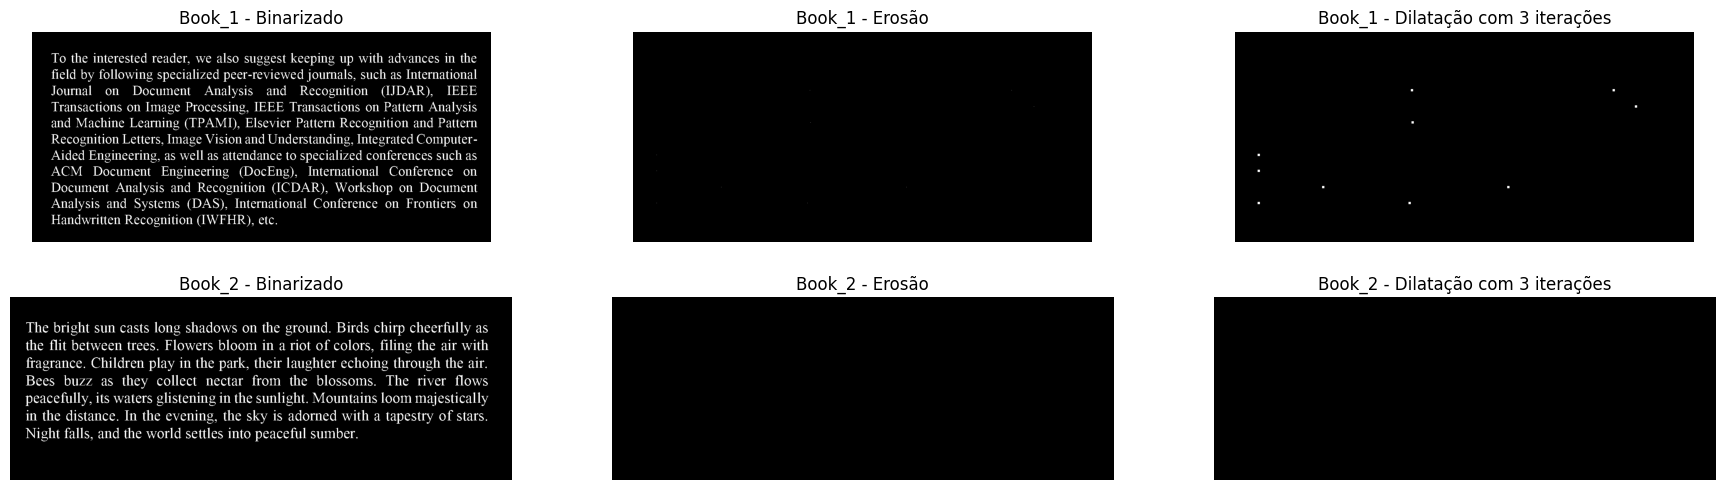

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(22, 6))
for idx, lista in enumerate(lista_books):
    ax[idx, 0].imshow(
        imgs_mask[lista],
        cmap="gray"
    )
    ax[idx, 1].imshow(
        eroded_results[lista]["eroded"],
        cmap="gray"
    )
    ax[idx, 2].imshow(
        dilated[lista],
        cmap="gray"
    )
    for _ax in ax[idx, :]:
        _ax.axis("off")
    ax[idx, 0].set_title(lista)
    ax[idx, 1].set_title(lista.split(" - ")[0] + " - Erosão")
    ax[idx, 2].set_title(lista.split(" - ")[0] + f" - Dilatação com {k_iter} iterações")
fig.savefig(path_assets / "atv02-q08-s1-03.png", dpi=400, bbox_inches='tight')

## 5) Conclusões

In [15]:
for key, content in eroded_results.items():
    print("-" * 30)
    print(key.split(" - ")[0])
    print(f"Possuí a letra A: {content['contains_A']}")
    if content["contains_A"]:
        print(f"Total de letra A: {content['total-of_A']}")
print("-"*30)

------------------------------
Book_1
Possuí a letra A: True
Total de letra A: 10
------------------------------
Book_2
Possuí a letra A: False
------------------------------


Apos a aplicação dessa solução, temos:

1) **Book_1:** a letra `A` foi detectada na imagem, além de terem sido identificados 10 letras na imagem, pela logica do algoritmo implementado no decorrer da solução.

2) **Book_2:** a letra `A` não foi detectada na imagem, pela logica do algoritmo implementado no decorrer da solução.